In [1]:
import pandas as pd
dataset = pd.read_csv("Social_Network_Ads.csv")

In [2]:
dataset.head(2)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


In [3]:
dataset = dataset.drop(columns=(['User ID']))

In [4]:
dataset.head(2)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0


In [5]:
dataset = pd.get_dummies(dataset, dtype=int, drop_first=True)

In [6]:
dataset.head(2)

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,1
1,35,20000,0,1


In [7]:
dataset.columns

Index(['Age', 'EstimatedSalary', 'Purchased', 'Gender_Male'], dtype='object')

In [8]:
independent=dataset[['Age', 'EstimatedSalary','Gender_Male']]
dependent=dataset[['Purchased']]

In [10]:
dependent.value_counts()

Purchased
0            257
1            143
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(independent, dependent, test_size=1/3, random_state=0)

In [13]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [14]:
X_train=sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

In [17]:
from sklearn.model_selection import GridSearchCV

In [18]:
param_grid = {'solver':['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
              'penalty':['l1', 'l2', 'elasticnet', None]}

In [19]:
grid = GridSearchCV(LogisticRegression(), param_grid, refit=True, verbose=3, n_jobs=-1, scoring='f1_weighted')

In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,LogisticRegression()
,param_grid,"{'penalty': ['l1', 'l2', ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [25]:
re=grid.cv_results_

In [27]:
grid_pred = grid.predict(X_test)

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

In [30]:
cm=confusion_matrix(y_test, grid_pred)
print(cm)

[[79  6]
 [10 39]]


In [31]:
clf=classification_report(y_test,grid_pred)
print(clf)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        85
           1       0.87      0.80      0.83        49

    accuracy                           0.88       134
   macro avg       0.88      0.86      0.87       134
weighted avg       0.88      0.88      0.88       134



In [32]:
print("The best grid parameter is {}".format(grid.best_params_))

The best grid parameter is {'penalty': 'l1', 'solver': 'saga'}


In [45]:
from sklearn.metrics import f1_score
f1_macro = f1_score(y_test,grid_pred,average='weighted')
print("The F1 value for the best grid parameter is {}".format(grid.best_params_), f1_macro)

The F1 value for the best grid parameter is {'penalty': 'l1', 'solver': 'saga'} 0.8794289739855382


In [34]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, grid.predict_proba(X_test)[:,1])

0.9493397358943578

In [35]:
import matplotlib.pyplot as plt
from sklearn import metrics

In [36]:
y_pred_proba= grid.predict_proba(X_test)[:,1]

In [37]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

In [38]:
roc_auc = metrics.roc_auc_score(y_test, y_pred_proba)

In [39]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

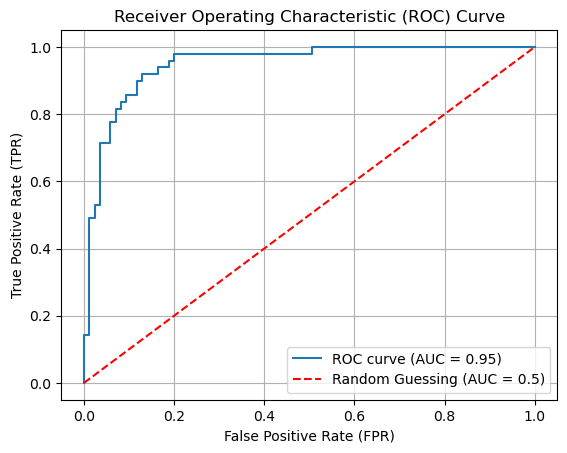

In [43]:
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guessing (AUC = 0.5)') # Diagonal baseline
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [47]:
table = pd.DataFrame.from_dict(re)
print(table)

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.002764      0.000631         0.000000        0.000000   
1        0.019662      0.002410         0.060716        0.006039   
2        0.004873      0.001592         0.000000        0.000000   
3        0.003735      0.001418         0.000000        0.000000   
4        0.002589      0.000672         0.000000        0.000000   
5        0.009410      0.003262         0.028893        0.007732   
6        0.016443      0.006981         0.024183        0.007142   
7        0.007999      0.002940         0.021376        0.002764   
8        0.011667      0.001164         0.018886        0.003194   
9        0.010684      0.003526         0.018643        0.001901   
10       0.005726      0.002588         0.015276        0.001441   
11       0.005184      0.000992         0.014771        0.001486   
12       0.001374      0.000768         0.000000        0.000000   
13       0.001146      0.000199         0.000000